In [1]:
import numpy as np
import pandas as pd
from matplotlib import cm
import matplotlib.pyplot as plt
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

#%mldev import

/Users/andrey/MIPT_projects/2023-project-119


In [2]:
print("Staprting Analysis of Variance.ipynb ...")
#%mldev start

Staprting Analysis of Variance.ipynb ...


```yaml

#%mldev nb_context

Analysis_of_Variance:
  - import
  - start
  - experiment_mode
  - paths
  - rc
  - prepare_data
  - make_3D_plot
  - sliding_window_setup
  - sampling_update_setup
```

In [3]:
experiment_mode = 'mldev'
#%mldev experiment_mode

In [4]:
# run this cell if you are in Jupyter and not running the notebook with mldev
experiment_mode = 'jupyter'

In [5]:
path_loop = os.getenv("MLDEV_VARIANCE_LOOP_PATH", default="results/hidden-loop_variance")
path_sample = os.getenv("MLDEV_VARIANCE_SAMPLE_PATH", default="results/hidden-sample_variance")
save_path = os.getenv("MLDEV_SAVEFIGURES_PATH", default="figures")
os.makedirs(save_path, exist_ok=True)
#%mldev paths

In [6]:
plt.rc('axes', titlesize=25, titleweight='bold') #fontsize of the title
plt.rc('axes', labelsize=20) #fontsize of the x and y labels
plt.rc('xtick', labelsize=20) #fontsize of the x tick labels
plt.rc('ytick', labelsize=20) #fontsize of the y tick labels
plt.rc('legend', fontsize=25) #fontsize of the legend
plt.rc('figure', figsize=(12, 8)) # figure size
#%mldev rc

In [12]:
# make pd.DataFrame from our results
def prepare_data(path, model_name='sgd_model_50', dataset_name='synthetic', 
                 run_times=10, chosen_step=1400):
    directory = Path(path)
    results = {}

    for folder in sorted(directory.iterdir()):
        if folder.name != '.DS_Store':
            noise, adherence, usage = folder.name.split('-')
            adherence = float(adherence)
            usage = float(usage)
            noise = float(noise)
            if noise not in results.keys():
                results[noise] = []

            deviation = 0.
            for trial in range(run_times):
                directory_full = f"{directory}/{folder.name}/{dataset_name}/{model_name}/{trial}"
                data = pd.read_csv(f"{directory_full}/dev_step_{chosen_step}.csv")
                deviation += np.std(data['y'] - data['y_pred'])
            row = {"adherence" : adherence,
                   "usage" : usage,
                   "deviation" : deviation / run_times}
            results[noise].append(row)

    for noise in results.keys():
        results[noise] = pd.DataFrame(results[noise])

    return results
#%mldev prepare_data

In [13]:
def make_3D_plot(results, model_name='sgd_model_50', dataset_name='synthetic',
                 experiment_name='sw', experiment_mode='jupyter'):
    for noise in sorted(results.keys()):
        adherence = results[noise]['adherence'].unique()
        adherence = sorted(adherence)
        usage = results[noise]['usage'].unique()
        usage = sorted(usage)
        X, Y = np.meshgrid(usage, adherence)

        Z = np.zeros(shape=(len(adherence), len(usage)))
        for i, us in enumerate(usage):
            for j, ad in enumerate(adherence):
                Z[j, i] = results[noise].where((results[noise]["adherence"] == ad) & (results[noise]["usage"] == us))["deviation"].max()
        
        fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize = (12, 10))

        #plot
        surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                            linewidth=0, antialiased=False)

        # Add a color bar which maps values to colors
        fig.colorbar(surf, shrink=0.5, aspect=5)

        ax.set_title(f"Deviation in original data = {noise}", 
                    fontsize = 20, fontweight='bold')
        ax.set_xlabel("usage", fontsize = 19, fontweight='bold')
        ax.set_ylabel("adherence", fontsize = 19, fontweight='bold')
        ax.set_zlabel("deviation", fontsize = 19, fontweight='bold')
        ax.tick_params(labelsize=14)
        plt.tight_layout()
        if experiment_mode == 'jupyter':
            plt.show()
        elif experiment_mode == 'mldev':
            plt.savefig(f"{save_path}/3D_{experiment_name}_{noise}_{dataset_name}_{model_name}.png")
            plt.close()
        else:
            raise ValueError(f"Wrong experiment mode {experiment_mode}!")
#%mldev make_3D_plot

## Sliding window setup

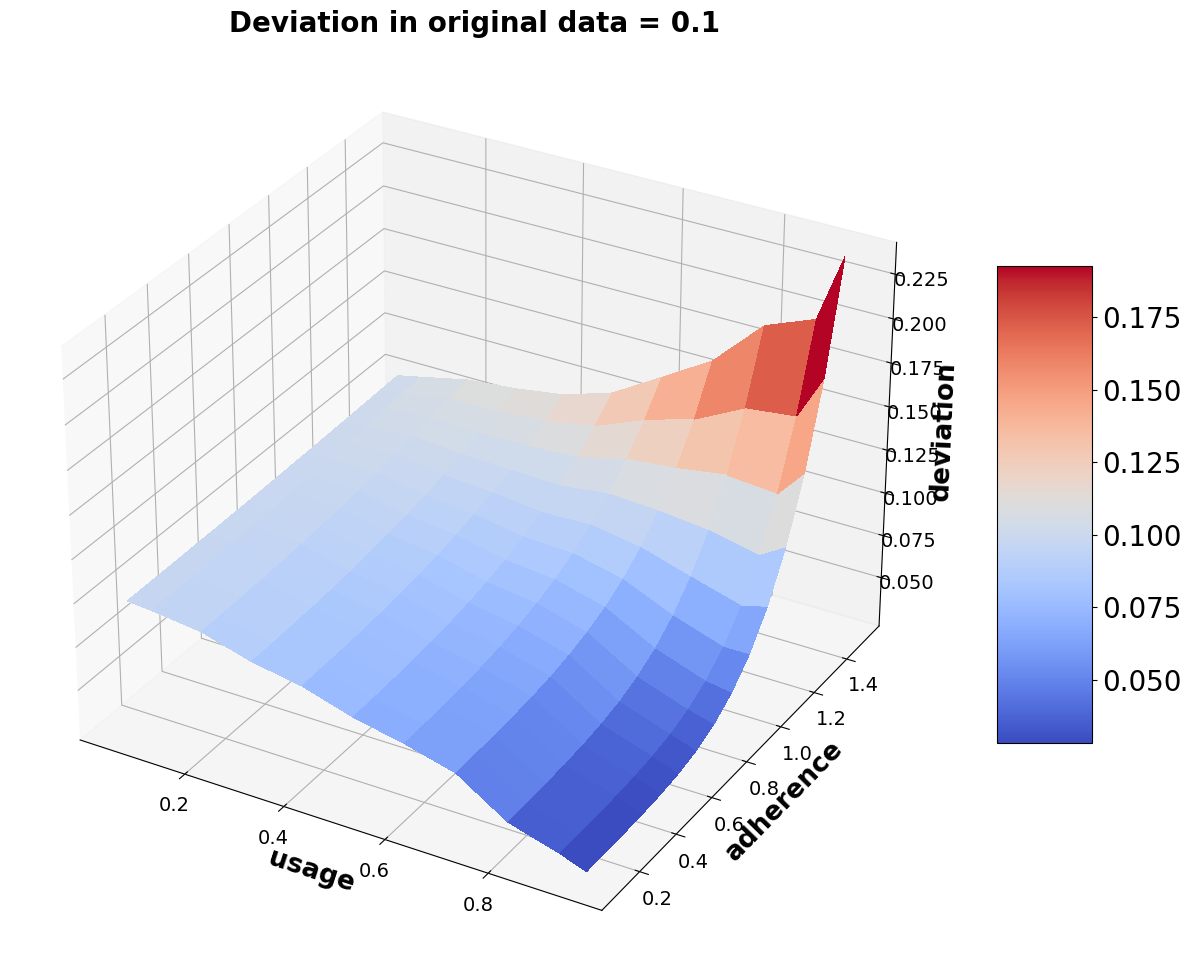

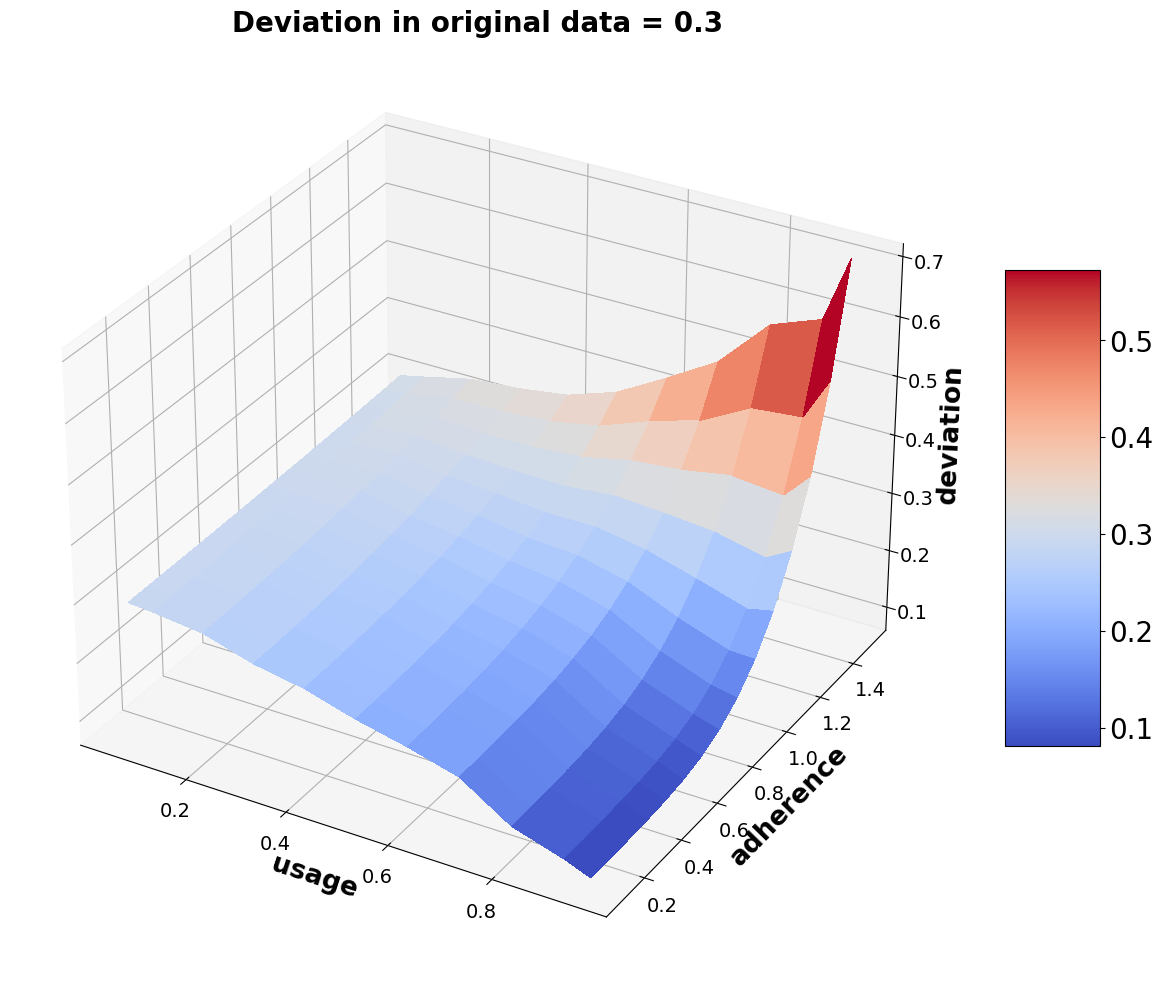

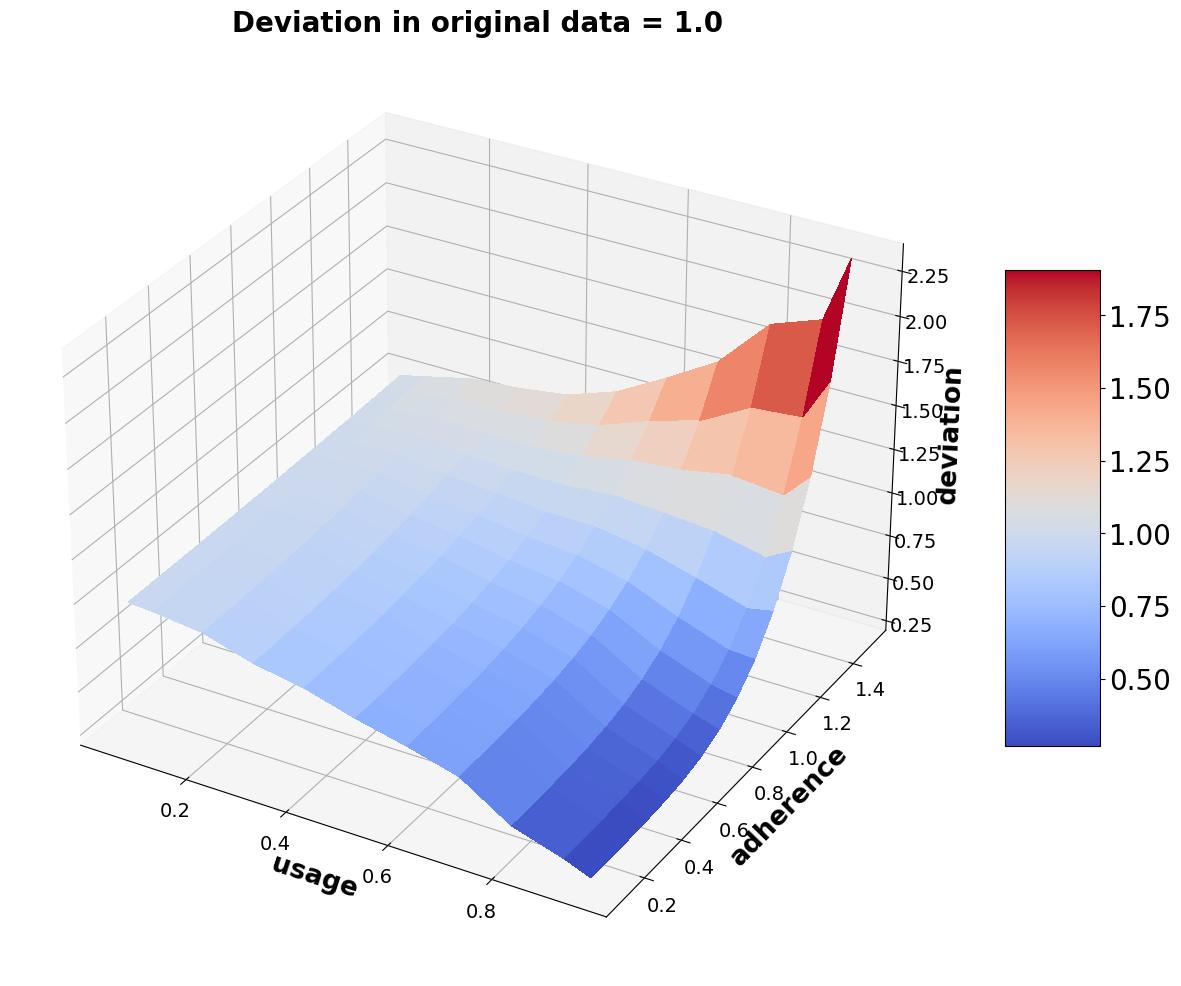

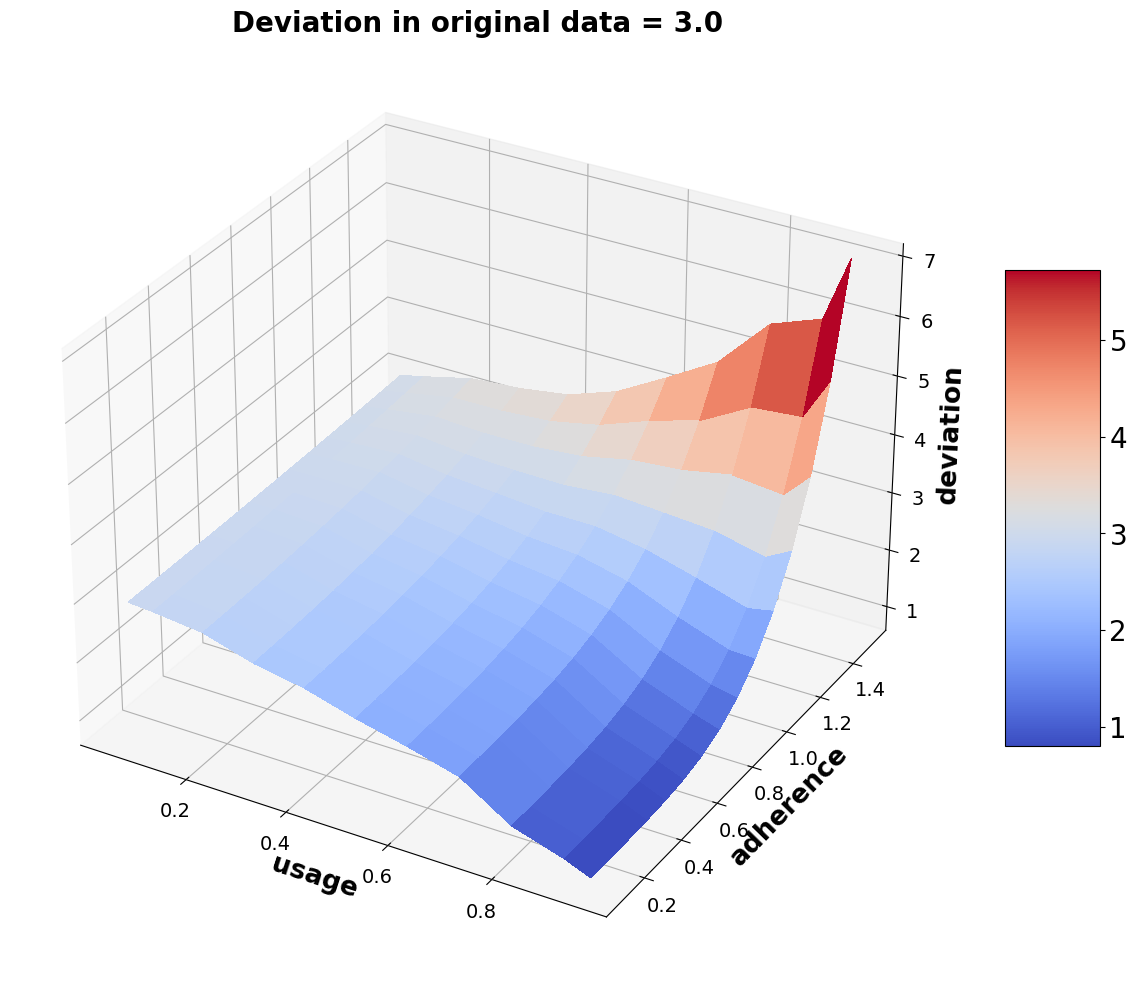

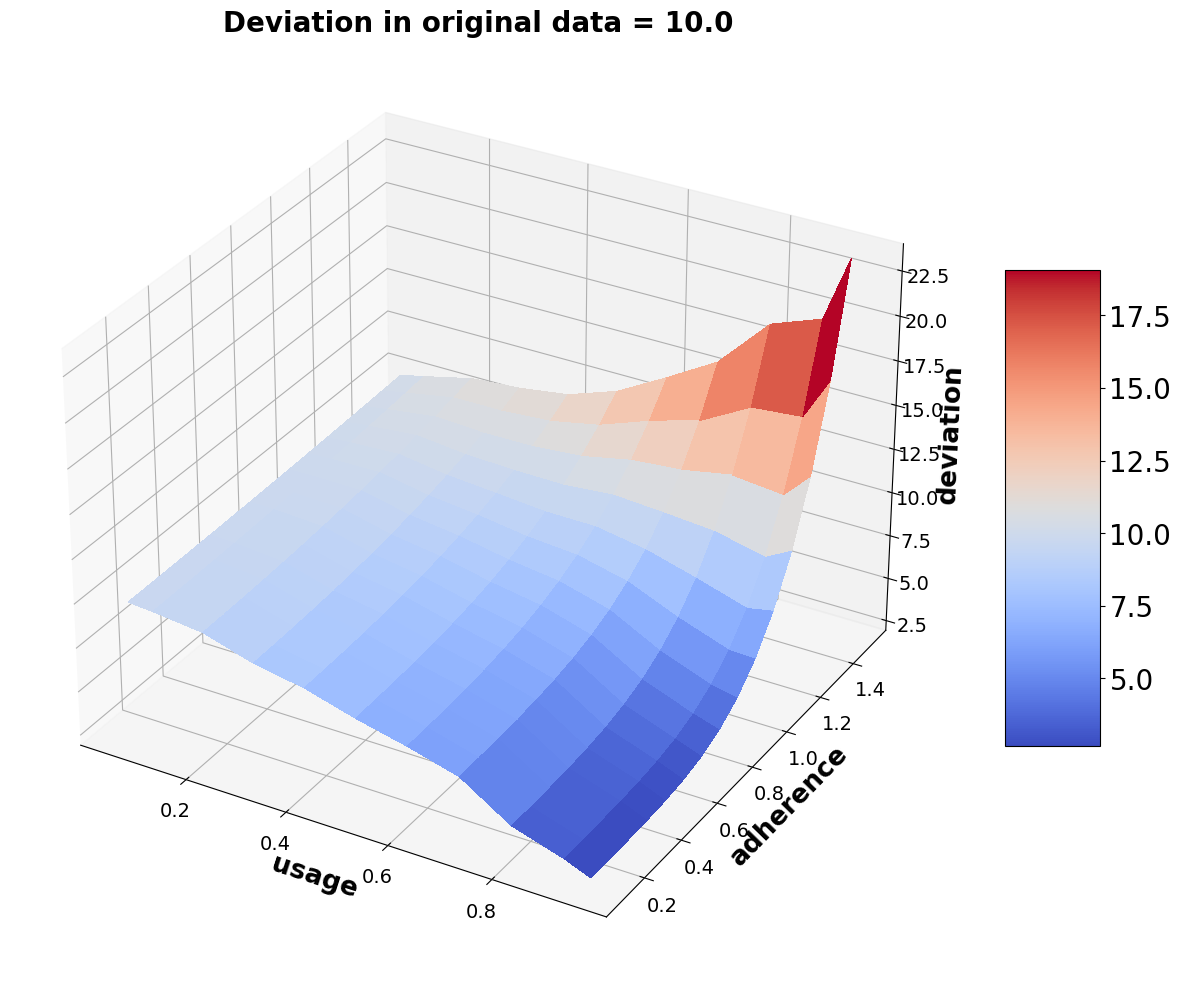

In [15]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
results = prepare_data(path=path_loop, model_name=model_name, 
                       dataset_name=dataset_name, run_times=10, chosen_step=1400)
make_3D_plot(results, model_name=model_name, dataset_name=dataset_name,
             experiment_mode=experiment_mode, experiment_name='sw')
#%mldev sliding_window_setup

## Sampling update setup

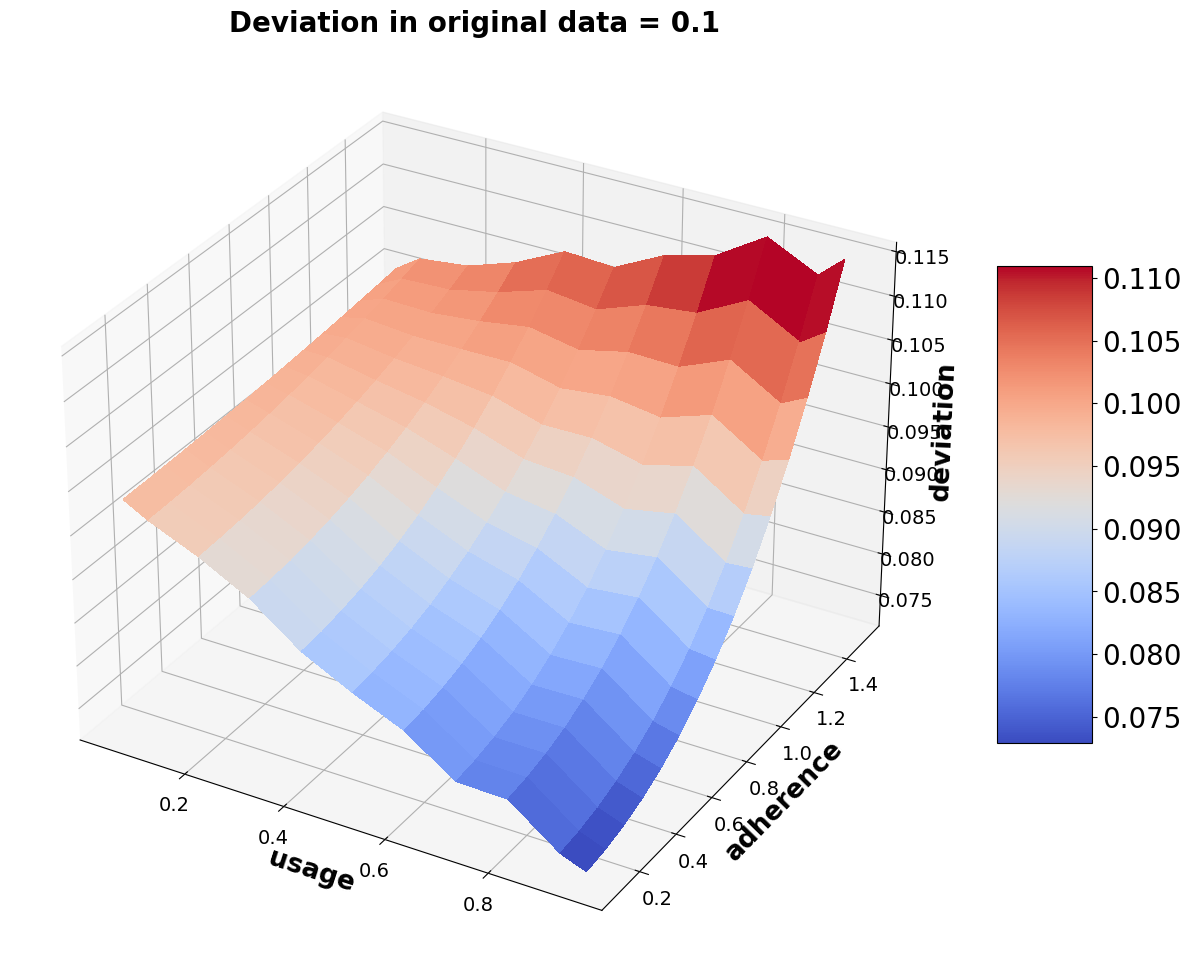

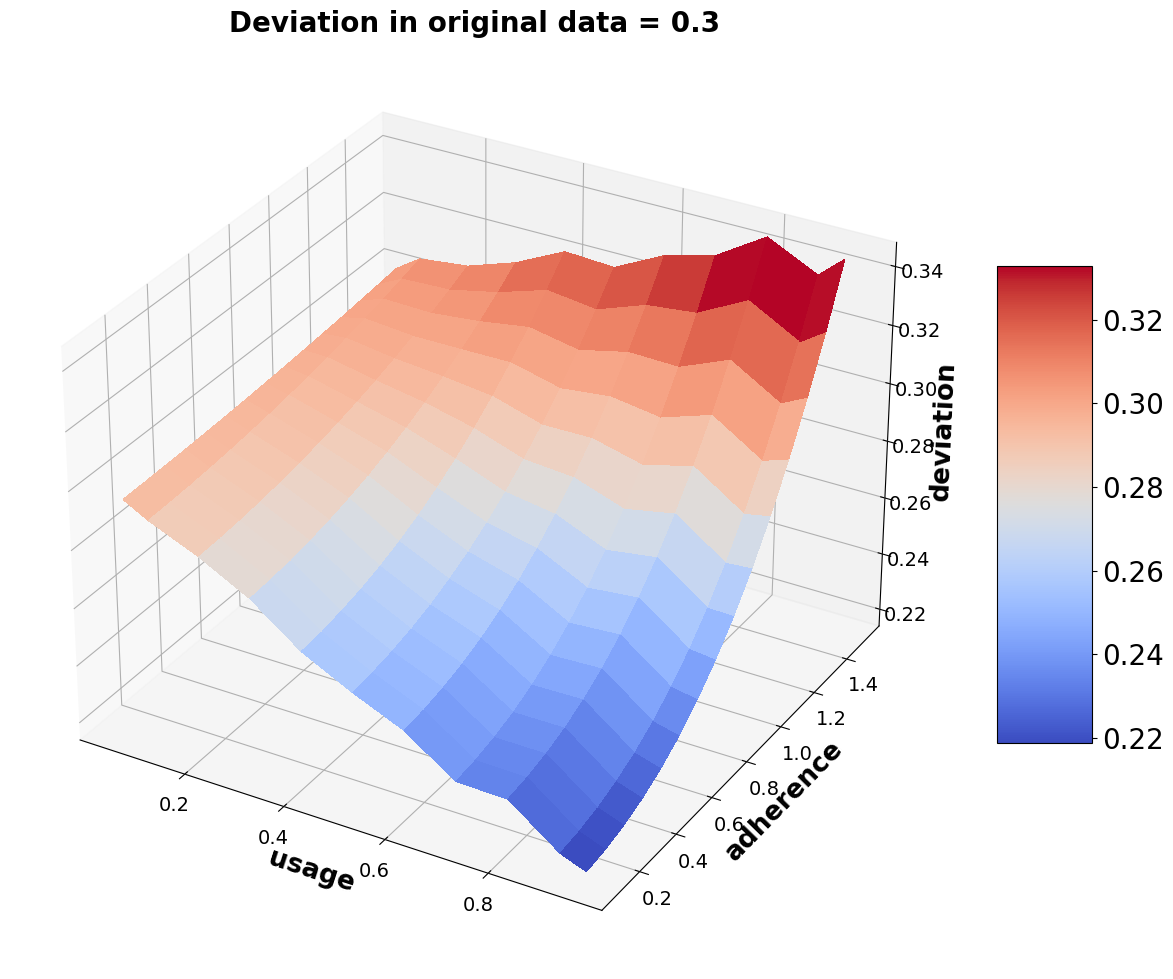

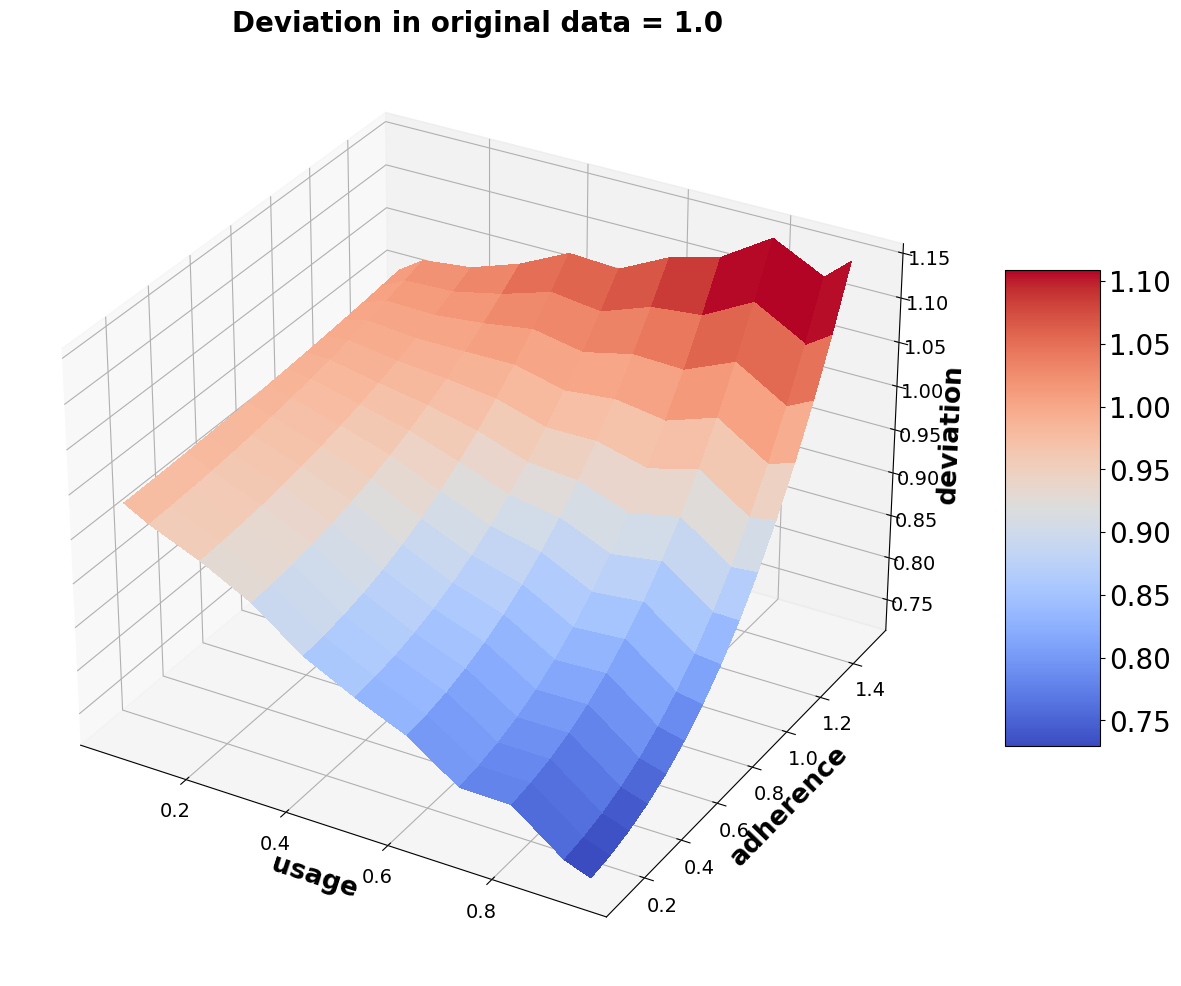

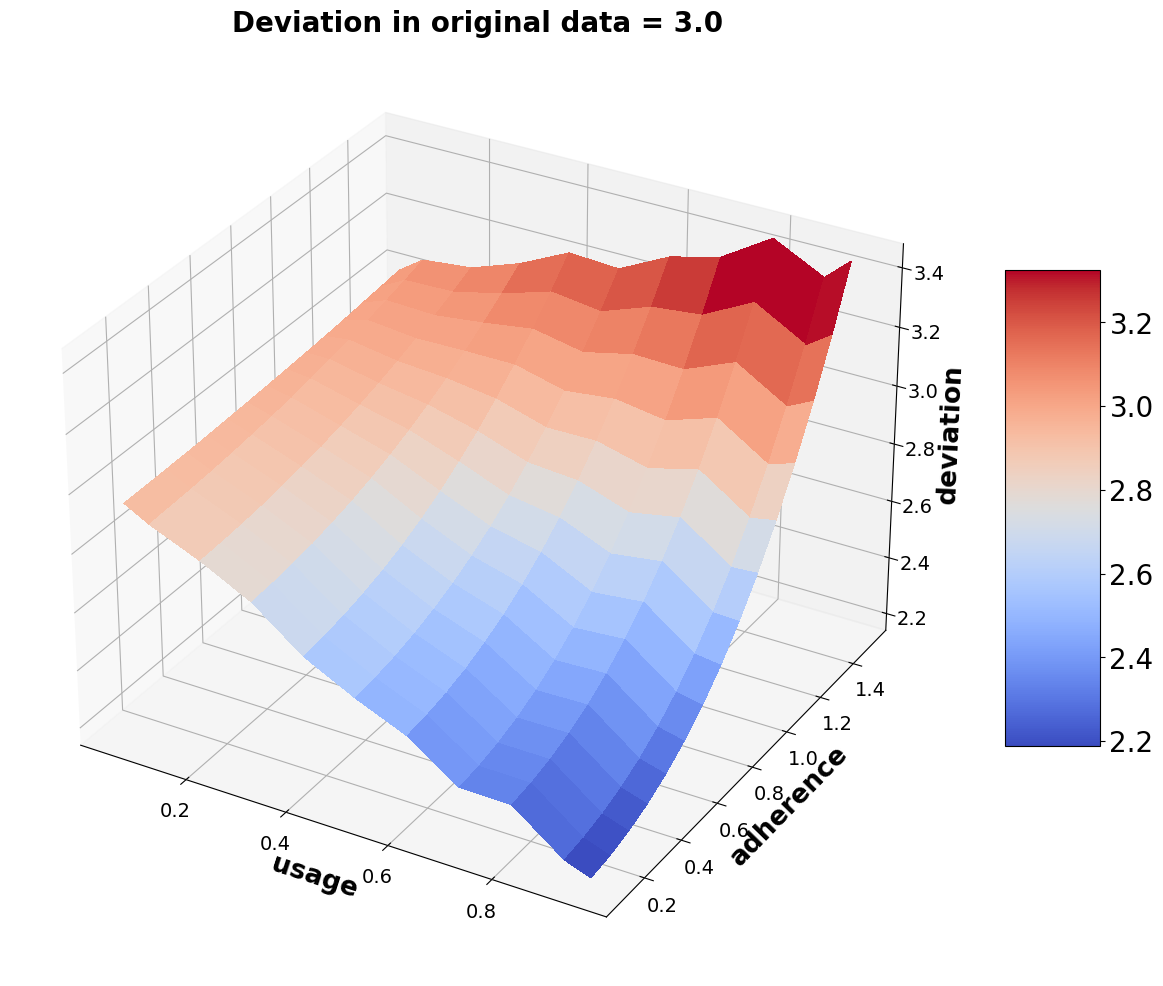

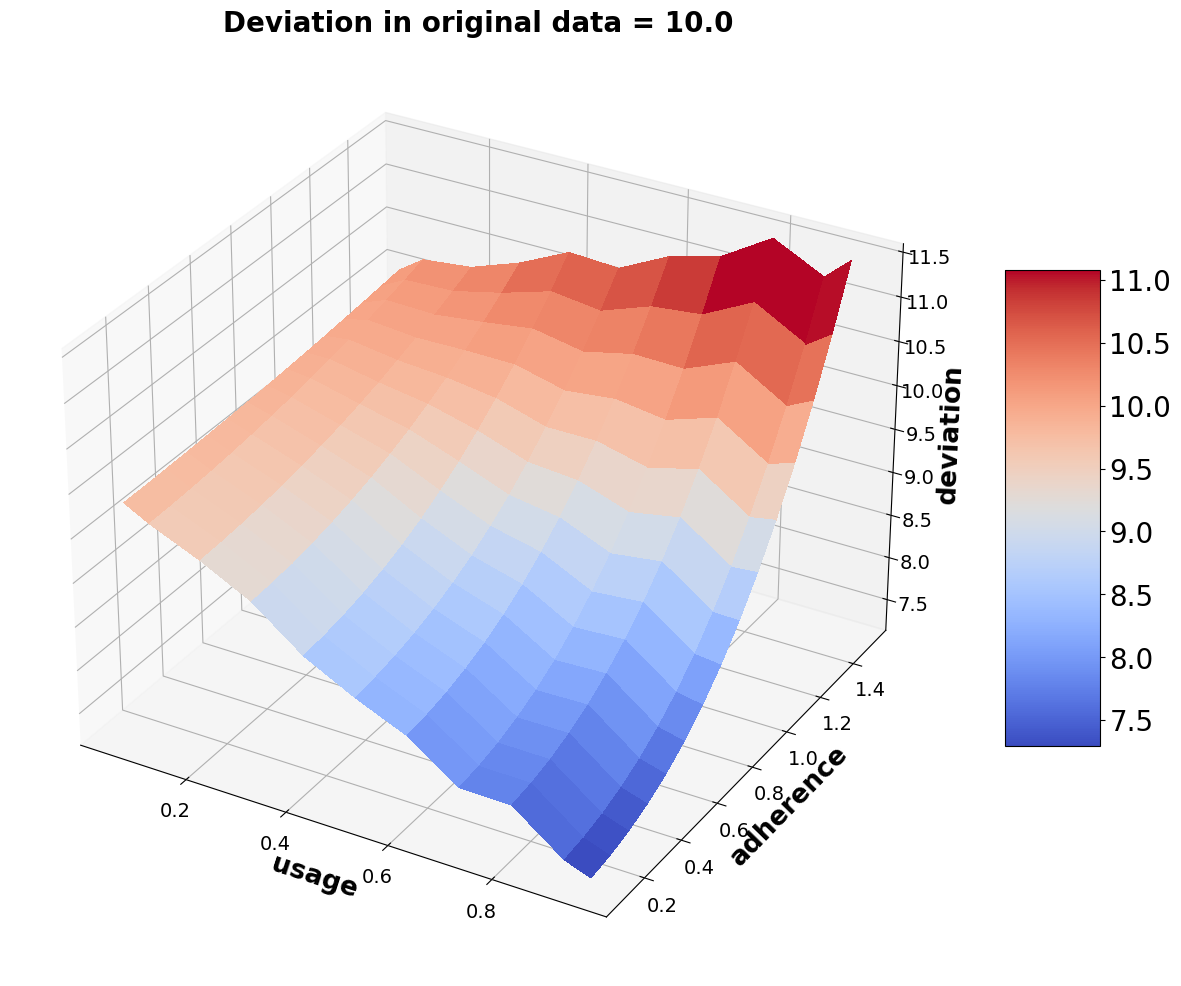

In [16]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
results = prepare_data(path=path_sample, model_name=model_name, 
                       dataset_name=dataset_name, run_times=10, chosen_step=1400)
make_3D_plot(results, model_name=model_name, dataset_name=dataset_name,
             experiment_mode=experiment_mode, experiment_name='su')
#%mldev sampling_update_setup